# L0.2 — The first result

**Level 0 · Core · 45 minutes**

**Goal.** You know the shape of an answer before you know how to make one.

**Check at the end.** You can say why one run is not a result, and how many runs are enough.

> The text in this course obeys ASD-STE100 Simplified Technical English.

## 0. Set up

Import everything first. Each import has a comment that says what the name does.

In [1]:
%matplotlib inline
import dataclasses

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False

from opencdarr import (
    MC,                  # the backend that runs many encounters and counts the losses
    MVP,                 # an avoidance algorithm
    M600,                # the limits of a DJI M600
    Agent,               # one aircraft: its state, plus what flies it
    Fixed,               # "hold this parameter still"
    GnssNavigation,      # a position sensor that makes mistakes
    Methods,             # the bundle of algorithms that a run uses
    PastCPA,             # decides when to stop the avoidance
    StateBased,          # decides whether a conflict exists
    Sweep,               # "change this parameter, one condition for each level"
    create_aircraft,
    create_conflict,
    estimate_p_los,      # runs many encounters and counts
    generator,           # makes a random generator from a seed sequence
    load_config,
    pairwise,            # builds a two-aircraft encounter for the estimator
    plot_pairwise,
    root_seed_sequence,
    run_experiment,      # runs many conditions and tabulates them
    run_fleet,           # runs one encounter
    spawn,               # splits one seed into independent substreams
)

RPZ = 50.0            # the radius of the protected zone [m]
BLUE, RED = "#1f77b4", "#d62728"
print("ready")

ready


## 1. Run one encounter

Build the two aircraft first.

- `create_aircraft(perf, ...)` makes the ownship. Give it an id, a position, a track, and a ground
  speed.
- `create_conflict(own, ...)` makes an intruder that is already in a conflict with the ownship. Give
  it the crossing angle `dpsi`, the miss distance `dcpa`, the time to the loss `tlos`, and the
  protected zone `rpz`.

Then give both to `run_fleet` inside an `Agent`. Set `record=True` if you want to plot the run.

conflict detected   True
separation lost     False
closest approach    103.4 m


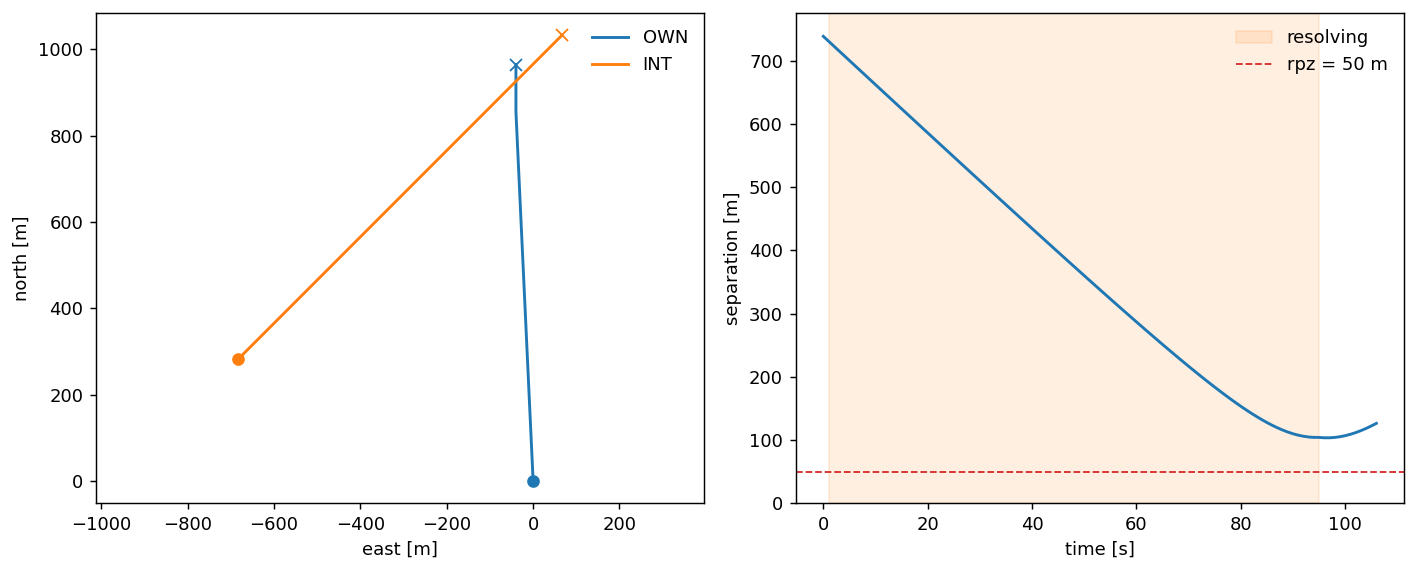

In [2]:
own = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
intr = create_conflict(own, intr_id="INT", dpsi=45.0, dcpa=0.0, tlos=90.0, rpz=RPZ)

clean = run_fleet(
    [Agent(own, M600), Agent(intr, M600)],
    rpz=RPZ,
    t_lookahead=120.0,          # predict 2 minutes ahead
    dt=1.0,                     # integrate in 1-second steps
    detector=StateBased(),
    resolver=MVP(margin=1.05),
    recovery=PastCPA(),
    t_max=600.0,
    record=True,
)

print(f"conflict detected   {clean.conflict}")
print(f"separation lost     {clean.los}")
print(f"closest approach    {clean.min_sep:.1f} m")

fig = plot_pairwise(clean, rpz=RPZ)

## 2. Add a sensor, and get a different answer each time

`run_fleet` has no randomness until you add a model that draws. To add a position error:

1. Put the accuracy on the **aircraft**, not on the model: `pos_ci95` and `vel_ci95` are fields of
   `AircraftState`. One fleet has one sensor model but many receivers, and they are not equally
   good.
2. Give `navigation=GnssNavigation()` to `run_fleet`.
3. Give `rng=` a generator. Make it from a seed, so that the run repeats.

Make the generator this way. Never use `np.random.default_rng()` directly here:

```python
nav_stream, comm_stream, broadcast_stream = spawn(root_seed_sequence(seed), 3)
rng = generator(nav_stream)
```

`spawn` gives each source of randomness its own substream from one root seed. Lesson L1.17 tells
you why this matters.

In [3]:
def one_encounter(seed: int) -> float:
    """Fly the same geometry with one seed. Return the closest approach [m]."""
    nav_stream, _, _ = spawn(root_seed_sequence(seed), 3)
    o = create_aircraft(M600, id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=10.0,
                        pos_ci95=80.0, vel_ci95=2.0)      # <- the sensor accuracy lives here
    i = create_conflict(o, intr_id="INT", dpsi=45.0, dcpa=0.0, tlos=60.0, rpz=RPZ)
    return run_fleet(
        [Agent(o, M600), Agent(i, M600)],
        rpz=RPZ, t_lookahead=120.0, dt=1.0,
        detector=StateBased(), resolver=MVP(margin=1.05), recovery=PastCPA(),
        navigation=GnssNavigation(),                       # <- the sensor model
        rng=generator(nav_stream),                         # <- its own substream
        t_max=600.0,
    ).min_sep

for seed in range(8):
    sep = one_encounter(seed)
    print(f"seed {seed}:  closest approach {sep:6.1f} m   {'LOSS' if sep < RPZ else ''}")

seed 0:  closest approach  207.4 m   
seed 1:  closest approach  101.0 m   
seed 2:  closest approach   67.9 m   
seed 3:  closest approach  106.0 m   
seed 4:  closest approach  110.9 m   
seed 5:  closest approach  100.6 m   
seed 6:  closest approach  105.5 m   
seed 7:  closest approach  201.4 m   


## 3. Run many encounters

Do not write the loop yourself. Use `estimate_p_los`. It needs four things:

| Argument | What to give it |
| --- | --- |
| `build` | An encounter builder. `pairwise(M600, dpsi=..., dcpa=...)` makes one for two aircraft. |
| `config` | A `Config`. Load `configs/pairwise.yaml` and change the fields that you need. |
| the methods | The detector, the resolver, and the recovery rule, in that order. |
| the CNS models | `navigation=`, and later `communication=` and `surveillance=`. |

Change a `Config` with `dataclasses.replace`. It is frozen, so you cannot assign to its fields.

Pin the geometry inside `pairwise(...)`. A pinned slot holds one value for every encounter. A slot
that you leave out is sampled from the config instead.

In [4]:
base = load_config("../../configs/pairwise.yaml")

cfg = dataclasses.replace(
    base,
    seed=0,
    n_encounters=2000,
    scenario=dataclasses.replace(
        base.scenario, speed=10.0, tlos=60.0, pos_ci95=80.0, vel_ci95=2.0,
    ),
)

result = estimate_p_los(
    pairwise(M600, dpsi=45.0, dcpa=0.0),      # pin the geometry, so only the noise changes
    cfg,
    StateBased(), MVP(margin=1.05), PastCPA(),
    GnssNavigation(),
)

print(f"encounters run      {result.n_encounters}")
print(f"losses counted      {result.n_los}")
print(f"P(LoS) for each run {result.p_los_run:.4f}")
print(f"P(LoS) per aircraft {result.p_los_ac:.4f}")
print(f"median closest      {result.median_min_sep:.1f} m")
print(f"detection rate      {result.detection_rate:.4f}   (a diagnostic, not the result)")

encounters run      2000
losses counted      133
P(LoS) for each run 0.0665
P(LoS) per aircraft 0.0665
median closest      129.7 m
detection rate      1.0000   (a diagnostic, not the result)


`estimate_p_los` returns a `MonteCarloEstimate`. Read its properties instead of counting yourself:

| Property | What it gives |
| --- | --- |
| `p_los_run` | Runs with a loss, divided by all runs. |
| `p_los_ac` | Aircraft in a loss, divided by the aircraft that flew. |
| `mean_k` | The mean number of losing pairs for each run. |
| `median_min_sep` | The median closest approach [m]. |
| `min_seps` | Every closest approach, one for each encounter. |
| `detection_rate` | How many runs the detector called a conflict. A diagnostic. |

At two aircraft, `p_los_run` and `p_los_ac` are the same number. Lesson L3.3 shows where they
separate.

## 4. Decide how many encounters are enough

A rate with no interval is not a result. The library does not ship an interval helper, so calculate
one here. The Wilson interval is correct for a small count of events, and the normal approximation
is not.

Take the first *n* closest approaches from the sample that you already have. Count the losses.
Calculate the interval. Repeat for a growing *n*.

  after  events  estimate          95 % interval
     25       2    0.0800   [0.0222, 0.2497]
     50       4    0.0800   [0.0315, 0.1884]
    100       9    0.0900   [0.0481, 0.1623]
    200      18    0.0900   [0.0577, 0.1378]
    400      28    0.0725   [0.0510, 0.1022]
    800      56    0.0700   [0.0543, 0.0898]
   1600     109    0.0681   [0.0568, 0.0815]
   2000     133    0.0665   [0.0564, 0.0783]


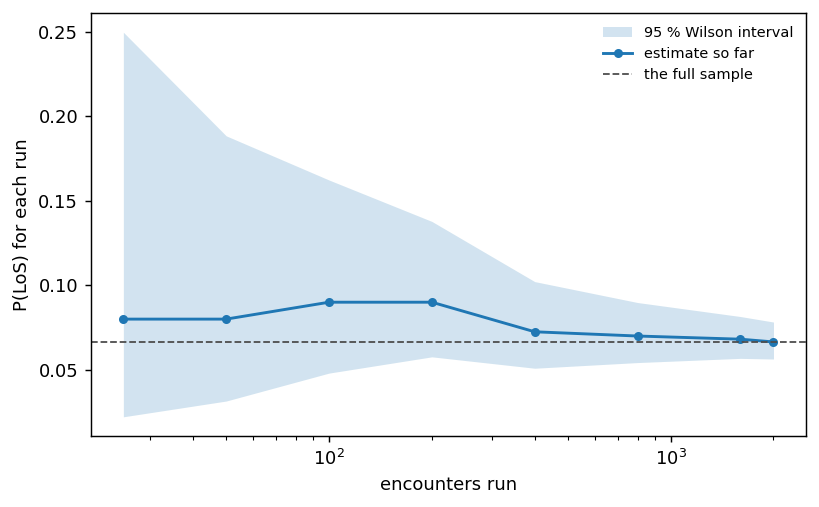

In [5]:
def wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """The 95 % Wilson interval for k successes in n trials."""
    if n == 0:
        return 0.0, 1.0
    p, d = k / n, 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return max(0.0, centre - half), min(1.0, centre + half)


seps = np.array(result.min_seps)
ns = [25, 50, 100, 200, 400, 800, 1600, 2000]
est, lo, hi = [], [], []
for n in ns:
    k = int((seps[:n] < RPZ).sum())
    a, b = wilson(k, n)
    est.append(k / n)
    lo.append(a)
    hi.append(b)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.fill_between(ns, lo, hi, alpha=0.2, color=BLUE, lw=0, label="95 % Wilson interval")
ax.plot(ns, est, marker="o", ms=4, lw=1.6, color=BLUE, label="estimate so far")
ax.axhline(result.p_los_run, color="0.3", lw=1.0, ls="--", label="the full sample")
ax.set_xscale("log")
ax.set_xlabel("encounters run")
ax.set_ylabel("P(LoS) for each run")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

print(f"{'after':>7} {'events':>7} {'estimate':>9}   {'95 % interval':>20}")
for n, e, a, b in zip(ns, est, lo, hi):
    print(f"{n:>7} {int(e * n):>7} {e:>9.4f}   [{a:.4f}, {b:.4f}]")

**The rule to use.** Size your sample by the count of the **events**, not by the count of the runs.
Aim for at least 50 losses. Below about 5 losses, report the count and the interval, and do not
report the rate alone.

## 5. Run many conditions

To compare conditions, do not write a loop over `estimate_p_los`. Declare the experiment once with
`run_experiment`. It takes four parts:

```python
run_experiment(
    {"pos_ci95": Sweep([...]), "vel_ci95": Fixed(2.0)},   # what changes, and what is held
    methods=Methods(detector=..., resolver=..., recovery=..., navigation=..., perf=...),
    backend=MC(n_encounters=800),                          # how to estimate each condition
    base_config=cfg,                                       # the defaults for everything else
    seed=0,
    n_jobs=4,                                              # spread the conditions over 4 cores
)
```

A parameter has one of two roles, and no third role:

- `Fixed(value)` — held at one value for every condition.
- `Sweep([...])` — an output axis. The experiment makes one condition for each level.

`navigation=GnssNavigation()` must be in the bundle. Without it, `pos_ci95` changes nothing.

In [6]:
study = run_experiment(
    {
        "pos_ci95": Sweep([0.0, 20.0, 40.0, 60.0, 80.0, 100.0]),   # the question
        "vel_ci95": Fixed(2.0),                                    # everything else, held still
        "dpsi": Fixed(45.0),
        "dcpa": Fixed(0.0),
        "tlos": Fixed(60.0),
        "speed": Fixed(10.0),
    },
    methods=Methods(
        detector=StateBased(), resolver=MVP(margin=1.05), recovery=PastCPA(),
        navigation=GnssNavigation(),
        perf=M600,
    ),
    backend=MC(n_encounters=800),
    base_config=cfg,
    seed=0,
    n_jobs=4,
)

rows = study.records()          # one dict for each condition
for r in rows:
    print(f"pos_ci95 {r['pos_ci95']:>5.0f} m   P(LoS) {r['p_los_run']:.4f}   "
          f"events {r['n_los']:>4d}   median closest {r['median_min_sep']:6.1f} m")

pos_ci95     0 m   P(LoS) 0.0013   events    1   median closest  123.7 m
pos_ci95    20 m   P(LoS) 0.0025   events    2   median closest  126.4 m
pos_ci95    40 m   P(LoS) 0.0037   events    3   median closest  128.6 m
pos_ci95    60 m   P(LoS) 0.0262   events   21   median closest  129.6 m
pos_ci95    80 m   P(LoS) 0.0700   events   56   median closest  128.6 m
pos_ci95   100 m   P(LoS) 0.1288   events  103   median closest  125.9 m


`run_experiment` returns an `ExperimentResult`. Read it in three ways:

| Call | What it gives |
| --- | --- |
| `res.records()` | One dict for each condition. |
| `res.frame()` | The same, as a pandas DataFrame. |
| `res.cell(pos_ci95=100.0)` | The raw estimate behind one condition. |

Plot the two metrics together. Report how often it failed, and how much room was left when it did
not.

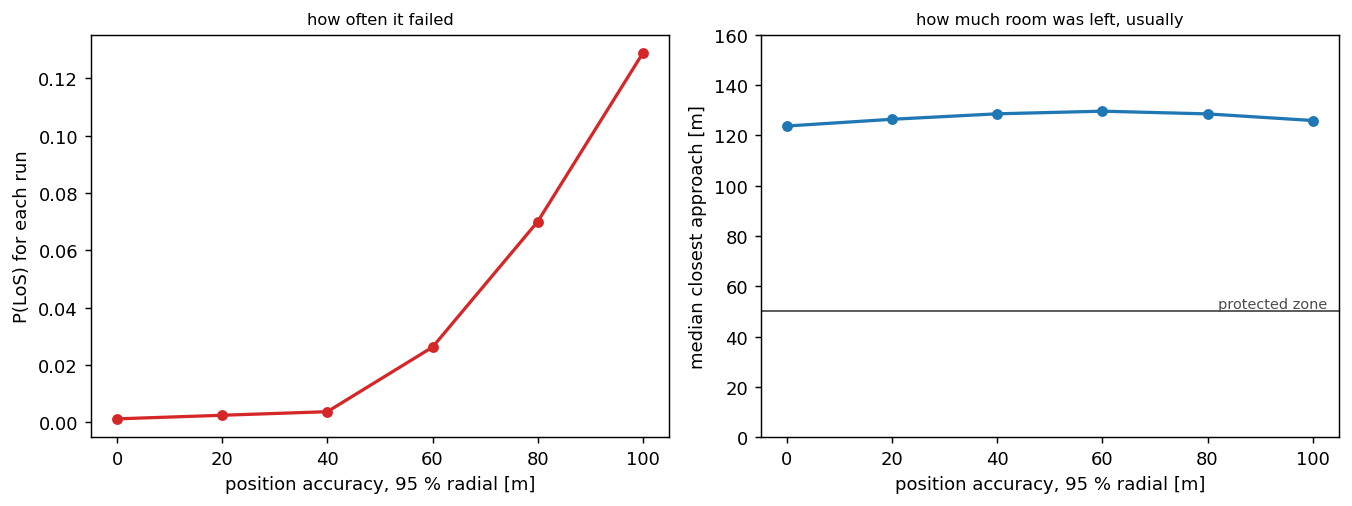

In [7]:
x = [r["pos_ci95"] for r in rows]

fig, (ax_p, ax_m) = plt.subplots(1, 2, figsize=(10.5, 4.0))

ax_p.plot(x, [r["p_los_run"] for r in rows], marker="o", ms=5, lw=1.8, color=RED)
ax_p.set_ylabel("P(LoS) for each run")
ax_p.set_title("how often it failed", fontsize=9)

ax_m.plot(x, [r["median_min_sep"] for r in rows], marker="o", ms=5, lw=1.8, color=BLUE)
ax_m.axhline(RPZ, color="0.3", lw=1.0)
ax_m.annotate("protected zone", (0.98, RPZ), xycoords=("axes fraction", "data"),
              ha="right", va="bottom", fontsize=8, color="0.3")
ax_m.set_ylim(0, 160)
ax_m.set_ylabel("median closest approach [m]")
ax_m.set_title("how much room was left, usually", fontsize=9)

for ax in (ax_p, ax_m):
    ax.set_xlabel("position accuracy, 95 % radial [m]")
fig.tight_layout()

## 6. Go back to the raw sample

The table gives you a rate. To answer a question that a rate cannot answer, get the sample behind
one condition with `res.cell(...)` and read its `min_seps`.

at pos_ci95 = 100 m, over 800 encounters:
  came within    50 m   0.1288
  came within    25 m   0.0750
  came within    10 m   0.0338
  the closest of all  0.1 m


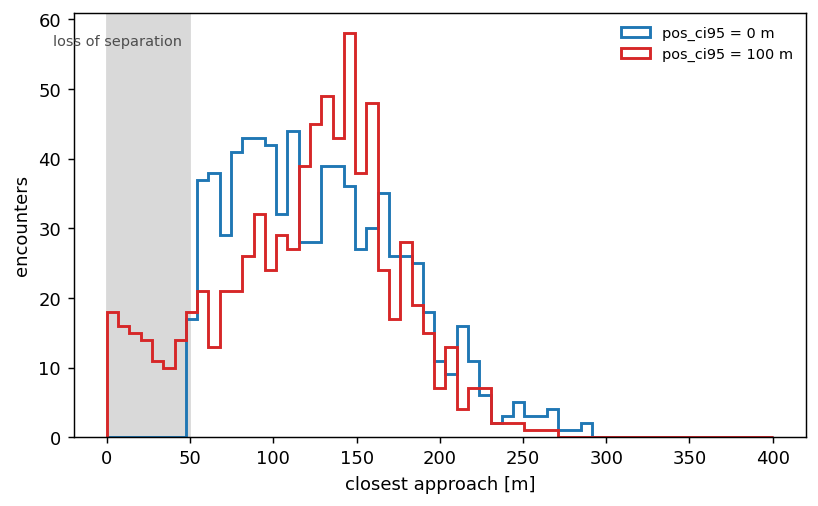

In [8]:
worst = study.cell(pos_ci95=100.0)
clean_cell = study.cell(pos_ci95=0.0)
s = np.array(worst.min_seps)

print(f"at pos_ci95 = 100 m, over {len(s)} encounters:")
for limit in (RPZ, 25.0, 10.0):
    print(f"  came within {limit:>5.0f} m   {(s < limit).mean():.4f}")
print(f"  the closest of all  {s.min():.1f} m")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
for cell, label, colour in ((clean_cell, "pos_ci95 = 0 m", BLUE), (worst, "pos_ci95 = 100 m", RED)):
    ax.hist(np.array(cell.min_seps), bins=np.linspace(0, 400, 60), histtype="step",
            lw=1.6, color=colour, label=label)
ax.axvspan(0, RPZ, color="0.85", zorder=0)
ax.annotate("loss of separation", (RPZ * 0.9, 0.95), xycoords=("data", "axes fraction"),
            ha="right", va="top", fontsize=8, color="0.3")
ax.set_xlabel("closest approach [m]")
ax.set_ylabel("encounters")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Do it yourself

1. Change `MVP(margin=1.05)` to `MVP(margin=1.3)` in the sweep. Run it again.
2. Change `dpsi` from `Fixed(45.0)` to `Sweep([20.0, 45.0, 90.0, 135.0])`. Count the conditions
   before you run it.
3. Set `n_encounters` to 200. Compare the intervals with the intervals at 800.

## Check

1. Why is one run not a result?
2. Which count decides your sample size: the runs, or the events?
3. The median closest approach and P(LoS) do not move together. Which one is the safety metric?
4. What does `res.cell(...)` give you that `res.records()` does not?

## Next

`L0.3 — Read the public surface`. You now know the shape of an answer. Next you find out where
every name in the library lives.